<a href="https://colab.research.google.com/github/mbrinkl5/ECGR-4106---Introduction-to-Deep-Learning/blob/main/ECGR4106_HW_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
import time

# **Problem 1**

# **RNN Model - sequence 10**

In [ ]:
text = """
Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.
"""


In [ ]:
#set(text): Creates a set of unique characters found in the text. The set function removes any duplicate characters.
#list(set(text)): Converts the set back into a list so that it can be sorted.
# sorted(list(set(text))): Sorts the list of unique characters.
chars = sorted(list(set(text)))
#This line creates a dictionary that maps each character to a unique index (integer)."
ix_to_char = {i: ch for i, ch in enumerate(chars)}
#Similar to the previous line, but in reverse. This line creates a dictionary that maps each unique index (integer) back to its corresponding character.
char_to_ix = {ch: i for i, ch in enumerate(chars)}
chars = sorted(list(set(text)))

In [ ]:
# Preparing the dataset
max_length = 10  # Maximum length of input sequences
X = []
y = []
for i in range(len(text) - max_length):
    sequence = text[i:i + max_length]
    label = text[i + max_length]
    X.append([char_to_ix[char] for char in sequence])
    y.append(char_to_ix[label])

X = np.array(X)
y = np.array(y)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Converting data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [ ]:
# Defining the RNN model
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        #This line takes the input tensor x, which contains indices of characters, and passes it through an embedding layer (self.embedding).
        #The embedding layer converts these indices into dense vectors of fixed size.
        #These vectors are learned during training and can capture semantic similarities between characters.
        #The result is a higher-dimensional representation of the input sequence, where each character index is replaced by its corresponding embedding vector.
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        #The RNN layer returns two outputs:
        #1- the output tensor containing the output of the RNN at each time step for each sequence in the batch,
        #2-the hidden state (_) of the last time step (which is not used in this line, hence the underscore).
        output, _ = self.rnn(embedded)
        #The RNN's output contains the outputs for every time step,
        #but for this task, we're only interested in the output of the last time step because we're predicting the next character after the sequence.
        #output[:, -1, :] selects the last time step's output for every sequence in the batch (-1 indexes the last item in Python).
        output = self.fc(output[:, -1, :])  # Get the output of the last RNN cell
        return output

In [ ]:
# Hyperparameters
hidden_size = 128
learning_rate = 0.005
epochs = 100

# Model, loss, and optimizer
model = CharRNN(len(chars), hidden_size, len(chars))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
# Training the model

start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())
        _, predicted = torch.max(val_output, 1)
        val_accuracy = (predicted == y_val).float().mean()
        val_accuracies.append(val_accuracy.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy.item():.4f}')


Epoch 10, Loss: 2.2111, Validation Loss: 2.3822, Validation Accuracy: 0.3480
Epoch 20, Loss: 1.7635, Validation Loss: 2.1195, Validation Accuracy: 0.4235
Epoch 30, Loss: 1.4086, Validation Loss: 2.0320, Validation Accuracy: 0.4696
Epoch 40, Loss: 1.0878, Validation Loss: 2.0035, Validation Accuracy: 0.5115
Epoch 50, Loss: 0.7977, Validation Loss: 2.0471, Validation Accuracy: 0.5220
Epoch 60, Loss: 0.5548, Validation Loss: 2.1704, Validation Accuracy: 0.5157
Epoch 70, Loss: 0.3431, Validation Loss: 2.3476, Validation Accuracy: 0.5136
Epoch 80, Loss: 0.2014, Validation Loss: 2.5285, Validation Accuracy: 0.5031
Epoch 90, Loss: 0.1201, Validation Loss: 2.6872, Validation Accuracy: 0.5073
Epoch 100, Loss: 0.0800, Validation Loss: 2.8112, Validation Accuracy: 0.5157



--- Training Summary ---
Sequence Length: 10
Final Training Loss: 0.0800
Final Validation Loss: 2.8112
Final Validation Accuracy: 0.5157
Training Time: 10.56 seconds
Parameter Count: 44589


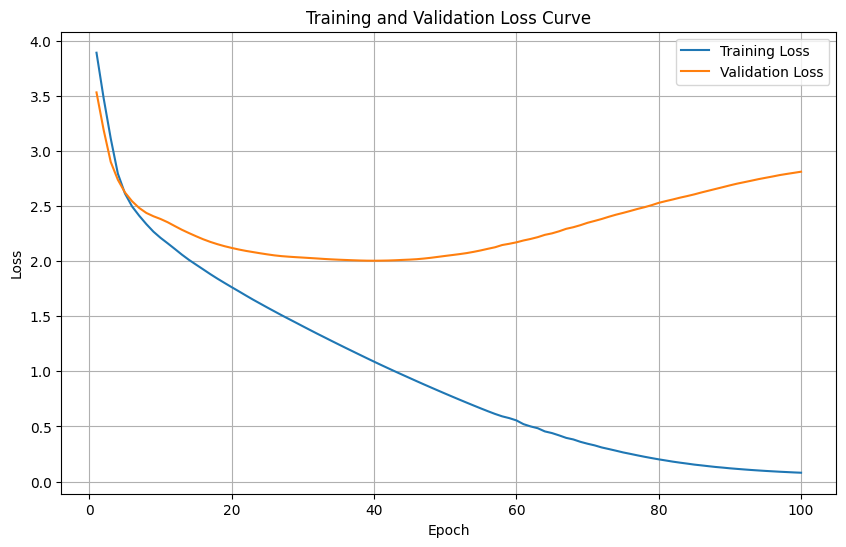

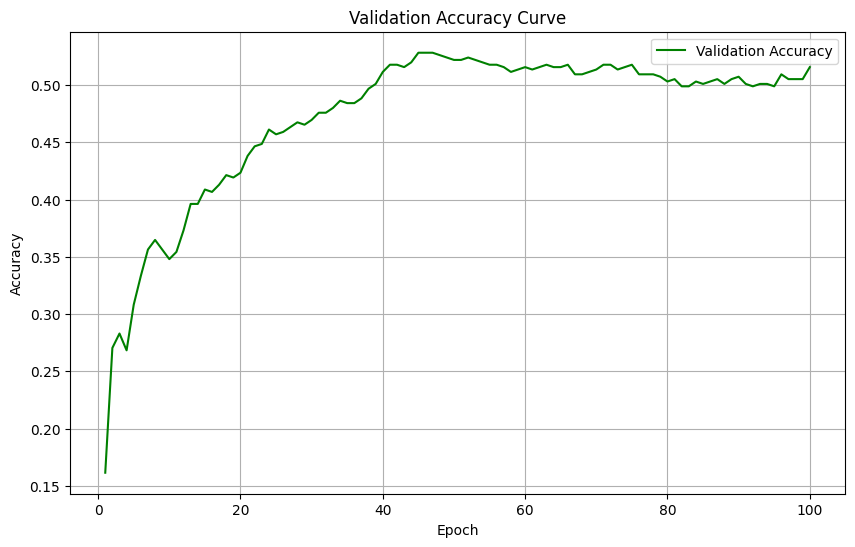

In [ ]:
end_time = time.time()
training_time = end_time - start_time

# Calculate parameter count
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Training Summary ---")
print(f"Sequence Length: {max_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}") # Use the last recorded training loss
print(f"Final Validation Loss: {val_losses[-1]:.4f}") # Use the last recorded validation loss
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}") # Use the last recorded validation accuracy
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {param_count}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


# **RNN - Sequnce of 20**

In [ ]:
# Preparing the dataset
max_length = 20
X = []
y = []
for i in range(len(text) - max_length):
    sequence = text[i:i + max_length]
    label = text[i + max_length]
    X.append([char_to_ix[char] for char in sequence])
    y.append(char_to_ix[label])

X = np.array(X)
y = np.array(y)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Converting data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [ ]:
# Defining the RNN model
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        #This line takes the input tensor x, which contains indices of characters, and passes it through an embedding layer (self.embedding).
        #The embedding layer converts these indices into dense vectors of fixed size.
        #These vectors are learned during training and can capture semantic similarities between characters.
        #The result is a higher-dimensional representation of the input sequence, where each character index is replaced by its corresponding embedding vector.
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        #The RNN layer returns two outputs:
        #1- the output tensor containing the output of the RNN at each time step for each sequence in the batch,
        #2-the hidden state (_) of the last time step (which is not used in this line, hence the underscore).
        output, _ = self.rnn(embedded)
        #The RNN's output contains the outputs for every time step,
        #but for this task, we're only interested in the output of the last time step because we're predicting the next character after the sequence.
        #output[:, -1, :] selects the last time step's output for every sequence in the batch (-1 indexes the last item in Python).
        output = self.fc(output[:, -1, :])  # Get the output of the last RNN cell
        return output

In [ ]:
# Hyperparameters
hidden_size = 128
learning_rate = 0.005
epochs = 100

# Model, loss, and optimizer
model = CharRNN(len(chars), hidden_size, len(chars))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
# Training the model

start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())
        _, predicted = torch.max(val_output, 1)
        val_accuracy = (predicted == y_val).float().mean()
        val_accuracies.append(val_accuracy.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy.item():.4f}')


Epoch 10, Loss: 2.2460, Validation Loss: 2.4481, Validation Accuracy: 0.3537
Epoch 20, Loss: 1.7852, Validation Loss: 2.2455, Validation Accuracy: 0.4189
Epoch 30, Loss: 1.4419, Validation Loss: 2.1246, Validation Accuracy: 0.4358
Epoch 40, Loss: 1.1429, Validation Loss: 2.0518, Validation Accuracy: 0.4716
Epoch 50, Loss: 0.8764, Validation Loss: 2.0567, Validation Accuracy: 0.4989
Epoch 60, Loss: 0.6364, Validation Loss: 2.1248, Validation Accuracy: 0.4947
Epoch 70, Loss: 0.4463, Validation Loss: 2.2284, Validation Accuracy: 0.4884
Epoch 80, Loss: 0.2938, Validation Loss: 2.3522, Validation Accuracy: 0.4926
Epoch 90, Loss: 0.1964, Validation Loss: 2.5064, Validation Accuracy: 0.4842
Epoch 100, Loss: 0.1428, Validation Loss: 2.6384, Validation Accuracy: 0.4800



--- Training Summary ---
Sequence Length: 20
Final Training Loss: 0.1428
Final Validation Loss: 2.6384
Final Validation Accuracy: 0.4800
Training Time: 17.20 seconds
Parameter Count: 44589


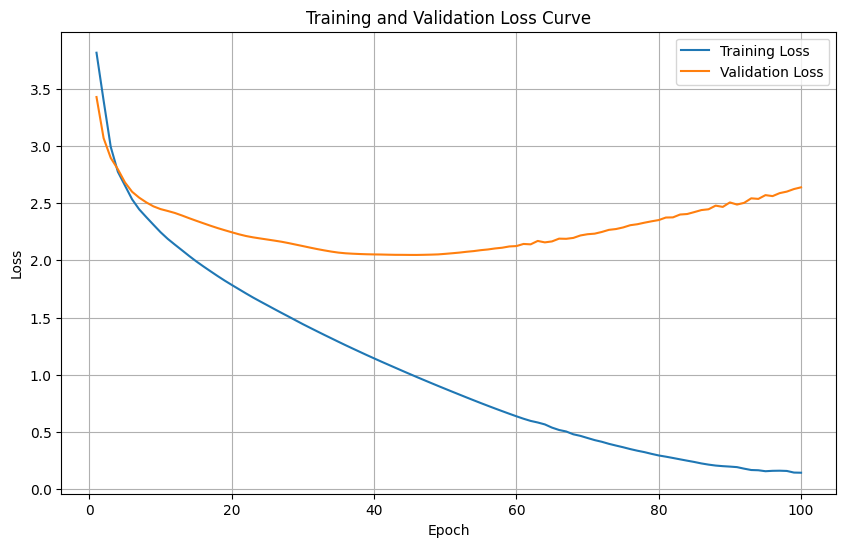

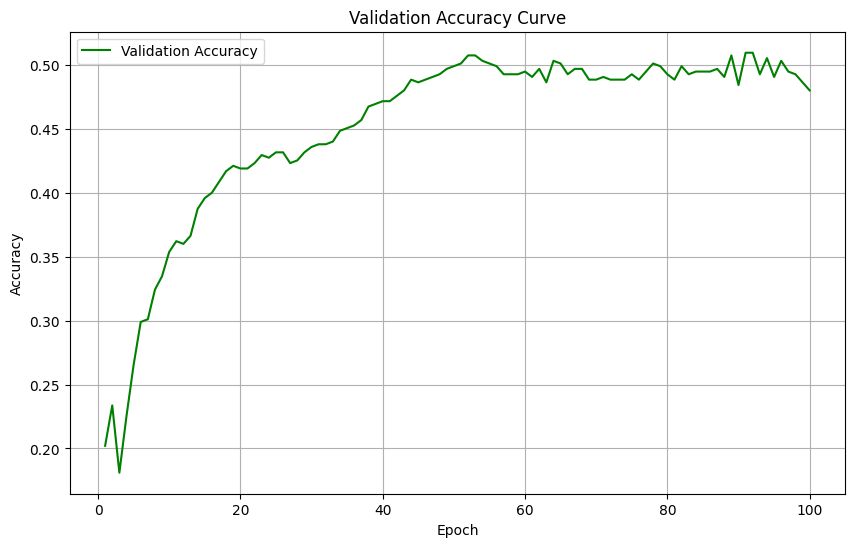

In [ ]:
end_time = time.time()
training_time = end_time - start_time

# Calculate parameter count
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Training Summary ---")
print(f"Sequence Length: {max_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}") # Use the last recorded training loss
print(f"Final Validation Loss: {val_losses[-1]:.4f}") # Use the last recorded validation loss
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}") # Use the last recorded validation accuracy
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {param_count}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


# **RNN - Sequnce of 30**

In [ ]:
# Preparing the dataset
max_length = 30
X = []
y = []
for i in range(len(text) - max_length):
    sequence = text[i:i + max_length]
    label = text[i + max_length]
    X.append([char_to_ix[char] for char in sequence])
    y.append(char_to_ix[label])

X = np.array(X)
y = np.array(y)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Converting data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [ ]:
# Hyperparameters
hidden_size = 128
learning_rate = 0.005
epochs = 100

# Model, loss, and optimizer
model = CharRNN(len(chars), hidden_size, len(chars))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
# Training the model

start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())
        _, predicted = torch.max(val_output, 1)
        val_accuracy = (predicted == y_val).float().mean()
        val_accuracies.append(val_accuracy.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy.item():.4f}')


Epoch 10, Loss: 2.2706, Validation Loss: 2.4019, Validation Accuracy: 0.3446
Epoch 20, Loss: 1.7920, Validation Loss: 2.1315, Validation Accuracy: 0.4228
Epoch 30, Loss: 1.4296, Validation Loss: 2.0341, Validation Accuracy: 0.4715
Epoch 40, Loss: 1.1102, Validation Loss: 2.0166, Validation Accuracy: 0.4693
Epoch 50, Loss: 0.8265, Validation Loss: 2.0440, Validation Accuracy: 0.4884
Epoch 60, Loss: 0.6204, Validation Loss: 2.1200, Validation Accuracy: 0.4905
Epoch 70, Loss: 0.4033, Validation Loss: 2.2448, Validation Accuracy: 0.4926
Epoch 80, Loss: 0.2616, Validation Loss: 2.3948, Validation Accuracy: 0.4947
Epoch 90, Loss: 0.1674, Validation Loss: 2.5532, Validation Accuracy: 0.4757
Epoch 100, Loss: 0.1060, Validation Loss: 2.7054, Validation Accuracy: 0.4799



--- Training Summary ---
Sequence Length: 30
Final Training Loss: 0.1060
Final Validation Loss: 2.7054
Final Validation Accuracy: 0.4799
Training Time: 48.03 seconds
Parameter Count: 44589


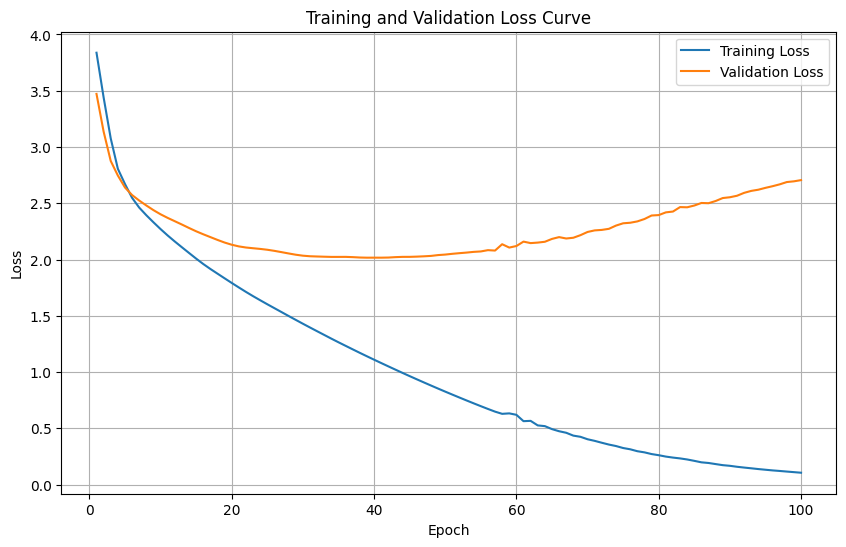

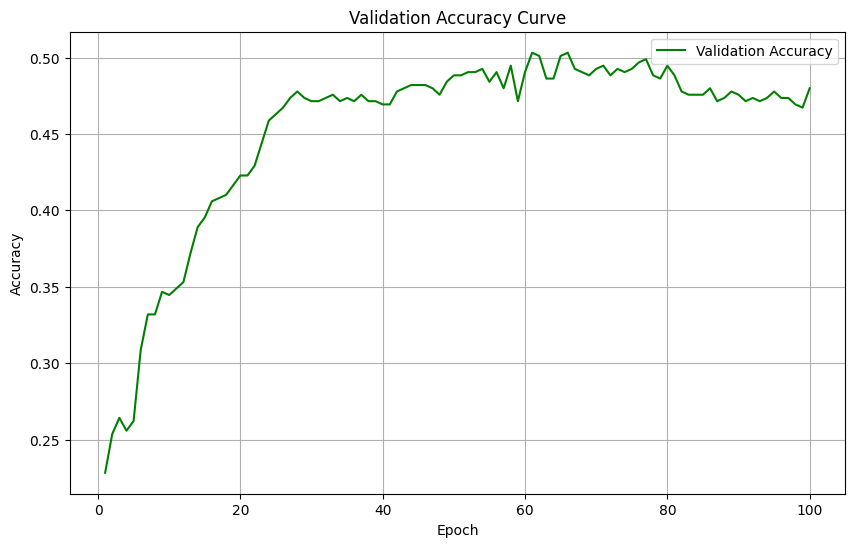

In [ ]:
end_time = time.time()
training_time = end_time - start_time

# Calculate parameter count
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Training Summary ---")
print(f"Sequence Length: {max_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}") # Use the last recorded training loss
print(f"Final Validation Loss: {val_losses[-1]:.4f}") # Use the last recorded validation loss
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}") # Use the last recorded validation accuracy
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {param_count}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


# **LSTM Model**

In [ ]:
# Preparing the dataset
max_length = 10
X = []
y = []
for i in range(len(text) - max_length):
    sequence = text[i:i + max_length]
    label = text[i + max_length]
    X.append([char_to_ix[char] for char in sequence])
    y.append(char_to_ix[label])

X = np.array(X)
y = np.array(y)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Converting data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [ ]:

class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        #This line takes the input tensor x, which contains indices of characters, and passes it through an embedding layer (self.embedding).
        #The embedding layer converts these indices into dense vectors of fixed size.
        #These vectors are learned during training and can capture semantic similarities between characters.
        #The result is a higher-dimensional representation of the input sequence, where each character index is replaced by its corresponding embedding vector.
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        #The RNN layer returns two outputs:
        #1- the output tensor containing the output of the RNN at each time step for each sequence in the batch,
        #2-the hidden state (_) of the last time step (which is not used in this line, hence the underscore).
        output, _ = self.rnn(embedded)
        #The RNN's output contains the outputs for every time step,
        #but for this task, we're only interested in the output of the last time step because we're predicting the next character after the sequence.
        #output[:, -1, :] selects the last time step's output for every sequence in the batch (-1 indexes the last item in Python).
        output = self.fc(output[:, -1, :])  # Get the output of the last RNN cell
        return output

In [ ]:
# Hyperparameters
hidden_size = 128
learning_rate = 0.005
epochs = 100

# Model, loss, and optimizer
model = CharRNN(len(chars), hidden_size, len(chars))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
# Training the model

start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())
        _, predicted = torch.max(val_output, 1)
        val_accuracy = (predicted == y_val).float().mean()
        val_accuracies.append(val_accuracy.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy.item():.4f}')


Epoch 10, Loss: 2.5228, Validation Loss: 2.5979, Validation Accuracy: 0.3061
Epoch 20, Loss: 2.0043, Validation Loss: 2.2488, Validation Accuracy: 0.3920
Epoch 30, Loss: 1.6137, Validation Loss: 2.0987, Validation Accuracy: 0.4403
Epoch 40, Loss: 1.2574, Validation Loss: 2.0156, Validation Accuracy: 0.4948
Epoch 50, Loss: 0.9340, Validation Loss: 2.0095, Validation Accuracy: 0.5073
Epoch 60, Loss: 0.6574, Validation Loss: 2.0708, Validation Accuracy: 0.5199
Epoch 70, Loss: 0.4294, Validation Loss: 2.1810, Validation Accuracy: 0.5115
Epoch 80, Loss: 0.2670, Validation Loss: 2.3011, Validation Accuracy: 0.5094
Epoch 90, Loss: 0.1638, Validation Loss: 2.4203, Validation Accuracy: 0.4906
Epoch 100, Loss: 0.1056, Validation Loss: 2.5470, Validation Accuracy: 0.4948



--- Training Summary ---
Sequence Length: 10
Final Training Loss: 0.1056
Final Validation Loss: 2.5470
Final Validation Accuracy: 0.4948
Training Time: 71.22 seconds
Parameter Count: 143661


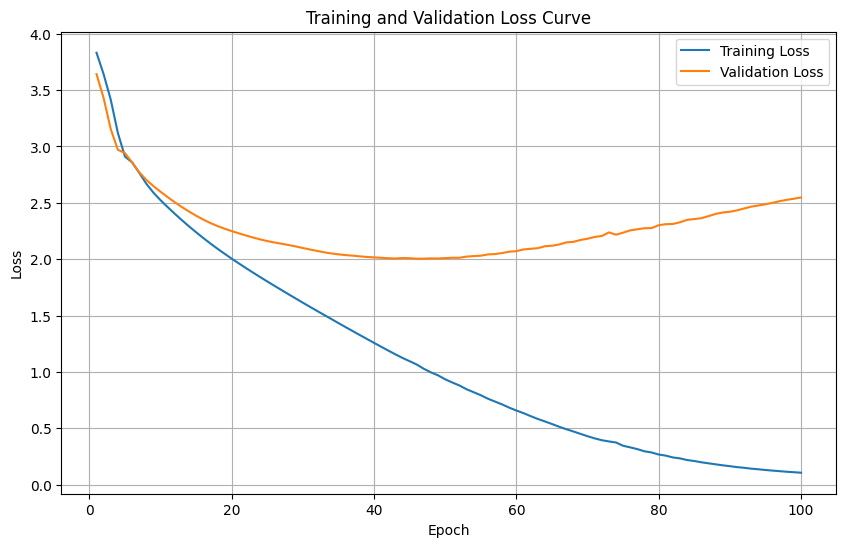

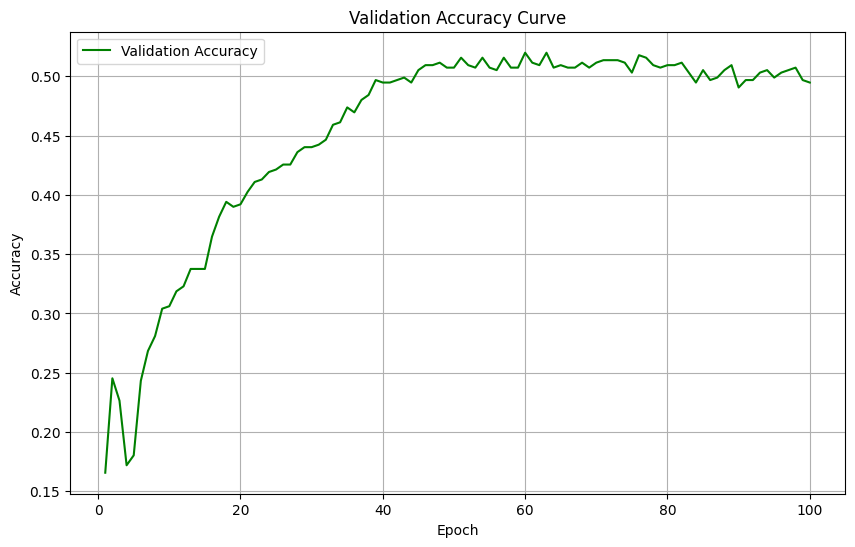

In [ ]:
end_time = time.time()
training_time = end_time - start_time

# Calculate parameter count
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Training Summary ---")
print(f"Sequence Length: {max_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}") # Use the last recorded training loss
print(f"Final Validation Loss: {val_losses[-1]:.4f}") # Use the last recorded validation loss
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}") # Use the last recorded validation accuracy
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {param_count}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


# **LSTM sequnce 20**

In [ ]:
# Preparing the dataset
max_length = 20
X = []
y = []
for i in range(len(text) - max_length):
    sequence = text[i:i + max_length]
    label = text[i + max_length]
    X.append([char_to_ix[char] for char in sequence])
    y.append(char_to_ix[label])

X = np.array(X)
y = np.array(y)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Converting data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [ ]:
# Training the model

start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())
        _, predicted = torch.max(val_output, 1)
        val_accuracy = (predicted == y_val).float().mean()
        val_accuracies.append(val_accuracy.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy.item():.4f}')


Epoch 10, Loss: 0.5485, Validation Loss: 1.0266, Validation Accuracy: 0.7453
Epoch 20, Loss: 0.3090, Validation Loss: 1.1305, Validation Accuracy: 0.6989
Epoch 30, Loss: 0.1744, Validation Loss: 1.2219, Validation Accuracy: 0.6695
Epoch 40, Loss: 0.1019, Validation Loss: 1.3127, Validation Accuracy: 0.6674
Epoch 50, Loss: 0.0657, Validation Loss: 1.3683, Validation Accuracy: 0.6526
Epoch 60, Loss: 0.0467, Validation Loss: 1.4046, Validation Accuracy: 0.6589
Epoch 70, Loss: 0.0356, Validation Loss: 1.4375, Validation Accuracy: 0.6568
Epoch 80, Loss: 0.0288, Validation Loss: 1.4731, Validation Accuracy: 0.6505
Epoch 90, Loss: 0.0243, Validation Loss: 1.5042, Validation Accuracy: 0.6484
Epoch 100, Loss: 0.0213, Validation Loss: 1.5304, Validation Accuracy: 0.6442



--- Training Summary ---
Sequence Length: 20
Final Training Loss: 0.0213
Final Validation Loss: 1.5304
Final Validation Accuracy: 0.6442
Training Time: 75.46 seconds
Parameter Count: 143661


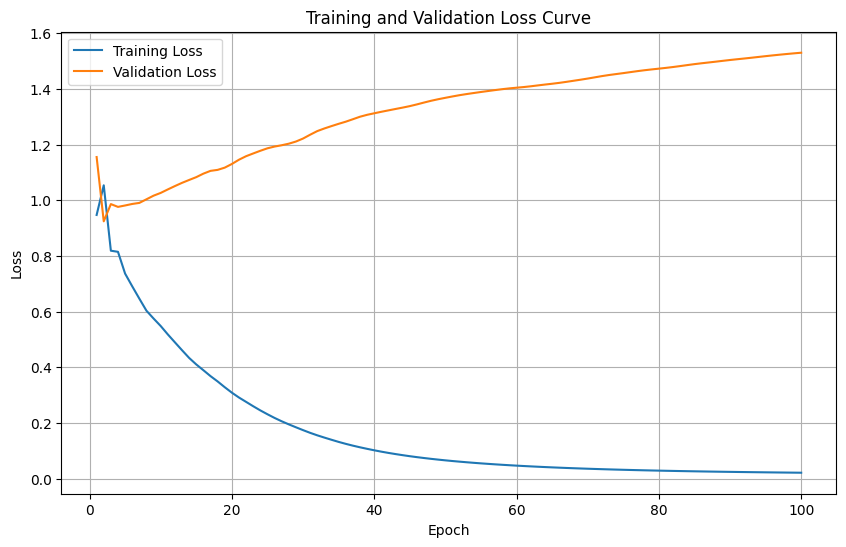

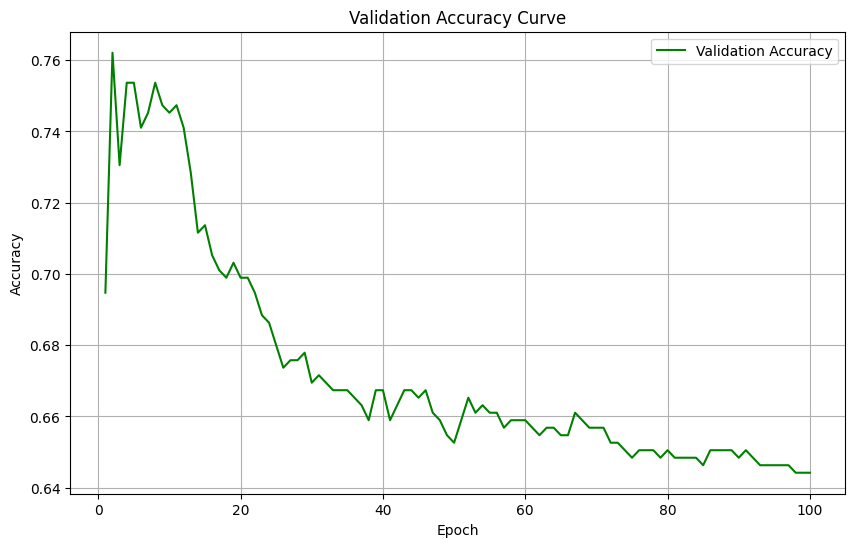

In [ ]:
end_time = time.time()
training_time = end_time - start_time

# Calculate parameter count
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Training Summary ---")
print(f"Sequence Length: {max_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}") # Use the last recorded training loss
print(f"Final Validation Loss: {val_losses[-1]:.4f}") # Use the last recorded validation loss
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}") # Use the last recorded validation accuracy
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {param_count}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


# **Seqence of 30**

In [ ]:
# Preparing the dataset
max_length = 30
X = []
y = []
for i in range(len(text) - max_length):
    sequence = text[i:i + max_length]
    label = text[i + max_length]
    X.append([char_to_ix[char] for char in sequence])
    y.append(char_to_ix[label])

X = np.array(X)
y = np.array(y)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Converting data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [ ]:
# Training the model

start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())
        _, predicted = torch.max(val_output, 1)
        val_accuracy = (predicted == y_val).float().mean()
        val_accuracies.append(val_accuracy.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy.item():.4f}')


Epoch 10, Loss: 0.1509, Validation Loss: 0.7086, Validation Accuracy: 0.8203
Epoch 20, Loss: 0.0673, Validation Loss: 0.7893, Validation Accuracy: 0.7907
Epoch 30, Loss: 0.0382, Validation Loss: 0.8155, Validation Accuracy: 0.7780
Epoch 40, Loss: 0.0254, Validation Loss: 0.8352, Validation Accuracy: 0.7717
Epoch 50, Loss: 0.0189, Validation Loss: 0.8566, Validation Accuracy: 0.7696
Epoch 60, Loss: 0.0154, Validation Loss: 0.8664, Validation Accuracy: 0.7738
Epoch 70, Loss: 0.0132, Validation Loss: 0.8814, Validation Accuracy: 0.7759
Epoch 80, Loss: 0.0117, Validation Loss: 0.8978, Validation Accuracy: 0.7717
Epoch 90, Loss: 0.0105, Validation Loss: 0.9089, Validation Accuracy: 0.7696
Epoch 100, Loss: 0.0096, Validation Loss: 0.9196, Validation Accuracy: 0.7653



--- Training Summary ---
Sequence Length: 30
Final Training Loss: 0.0096
Final Validation Loss: 0.9196
Final Validation Accuracy: 0.7653
Training Time: 113.10 seconds
Parameter Count: 143661


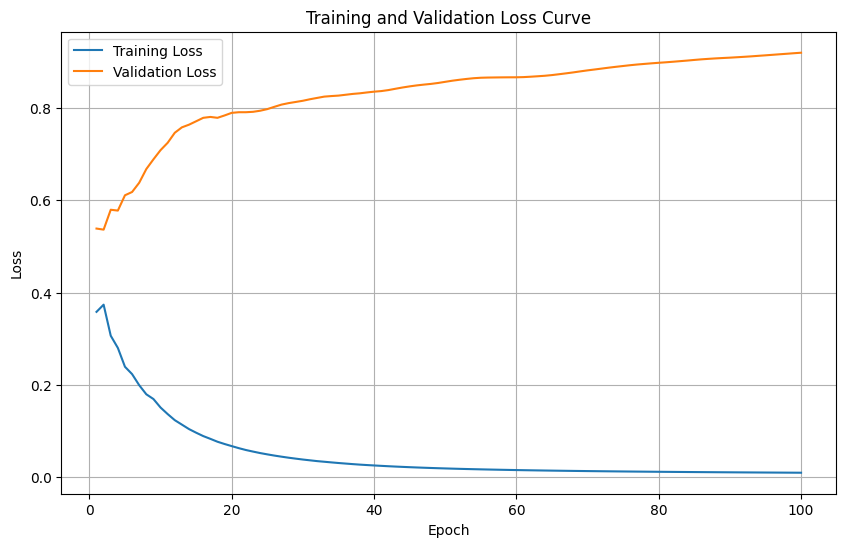

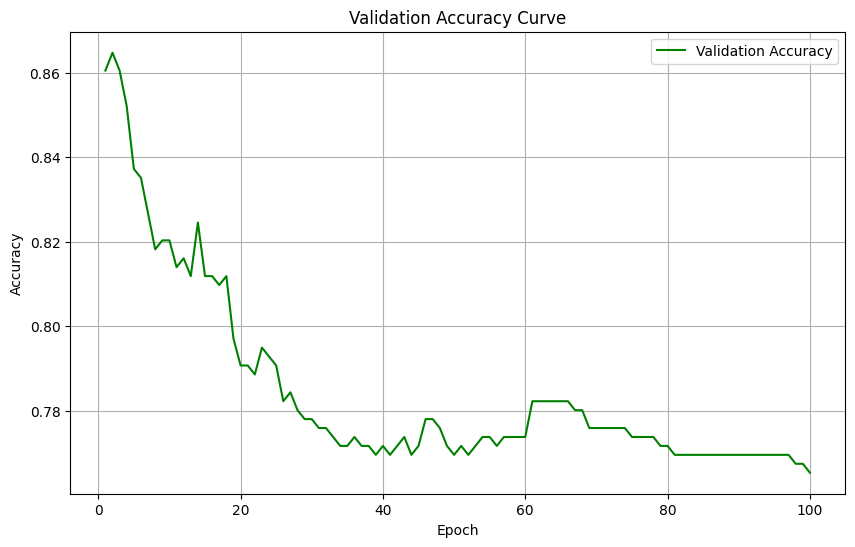

In [ ]:
end_time = time.time()
training_time = end_time - start_time

# Calculate parameter count
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Training Summary ---")
print(f"Sequence Length: {max_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}") # Use the last recorded training loss
print(f"Final Validation Loss: {val_losses[-1]:.4f}") # Use the last recorded validation loss
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}") # Use the last recorded validation accuracy
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {param_count}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


# **GRU Model**

In [ ]:
# Preparing the dataset
max_length = 10
X = []
y = []
for i in range(len(text) - max_length):
    sequence = text[i:i + max_length]
    label = text[i + max_length]
    X.append([char_to_ix[char] for char in sequence])
    y.append(char_to_ix[label])

X = np.array(X)
y = np.array(y)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Converting data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [ ]:

class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        #This line takes the input tensor x, which contains indices of characters, and passes it through an embedding layer (self.embedding).
        #The embedding layer converts these indices into dense vectors of fixed size.
        #These vectors are learned during training and can capture semantic similarities between characters.
        #The result is a higher-dimensional representation of the input sequence, where each character index is replaced by its corresponding embedding vector.
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        #The RNN layer returns two outputs:
        #1- the output tensor containing the output of the RNN at each time step for each sequence in the batch,
        #2-the hidden state (_) of the last time step (which is not used in this line, hence the underscore).
        output, _ = self.rnn(embedded)
        #The RNN's output contains the outputs for every time step,
        #but for this task, we're only interested in the output of the last time step because we're predicting the next character after the sequence.
        #output[:, -1, :] selects the last time step's output for every sequence in the batch (-1 indexes the last item in Python).
        output = self.fc(output[:, -1, :])  # Get the output of the last RNN cell
        return output

In [ ]:
# Hyperparameters
hidden_size = 128
learning_rate = 0.005
epochs = 100

# Model, loss, and optimizer
model = CharRNN(len(chars), hidden_size, len(chars))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
# Training the model

start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())
        _, predicted = torch.max(val_output, 1)
        val_accuracy = (predicted == y_val).float().mean()
        val_accuracies.append(val_accuracy.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy.item():.4f}')


Epoch 10, Loss: 2.4046, Validation Loss: 2.5075, Validation Accuracy: 0.3501
Epoch 20, Loss: 1.8848, Validation Loss: 2.1497, Validation Accuracy: 0.4256
Epoch 30, Loss: 1.4739, Validation Loss: 1.9741, Validation Accuracy: 0.4591
Epoch 40, Loss: 1.1049, Validation Loss: 1.9240, Validation Accuracy: 0.4906
Epoch 50, Loss: 0.7736, Validation Loss: 1.9410, Validation Accuracy: 0.5115
Epoch 60, Loss: 0.4982, Validation Loss: 2.0364, Validation Accuracy: 0.5178
Epoch 70, Loss: 0.2938, Validation Loss: 2.1759, Validation Accuracy: 0.5178
Epoch 80, Loss: 0.1661, Validation Loss: 2.3421, Validation Accuracy: 0.5052
Epoch 90, Loss: 0.0988, Validation Loss: 2.4875, Validation Accuracy: 0.5010
Epoch 100, Loss: 0.0675, Validation Loss: 2.6099, Validation Accuracy: 0.5052



--- Training Summary ---
Sequence Length: 10
Final Training Loss: 0.0675
Final Validation Loss: 2.6099
Final Validation Accuracy: 0.5052
Training Time: 27.34 seconds
Parameter Count: 110637


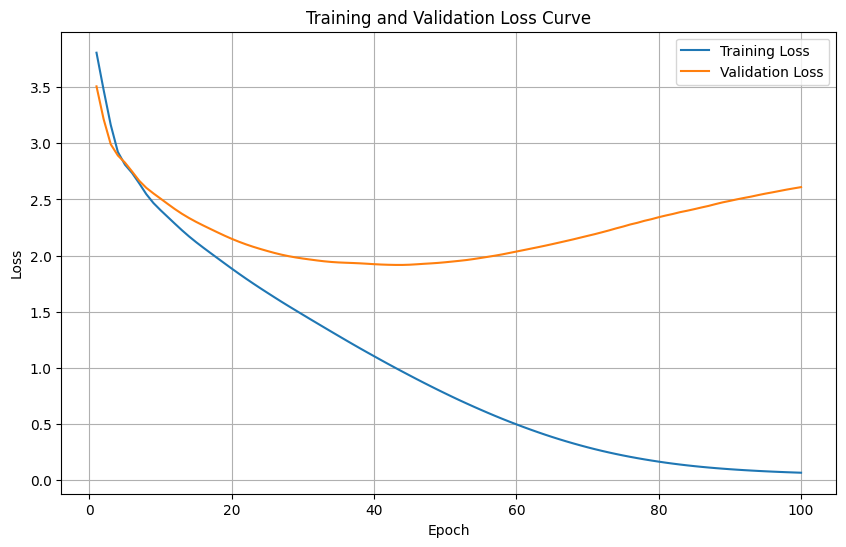

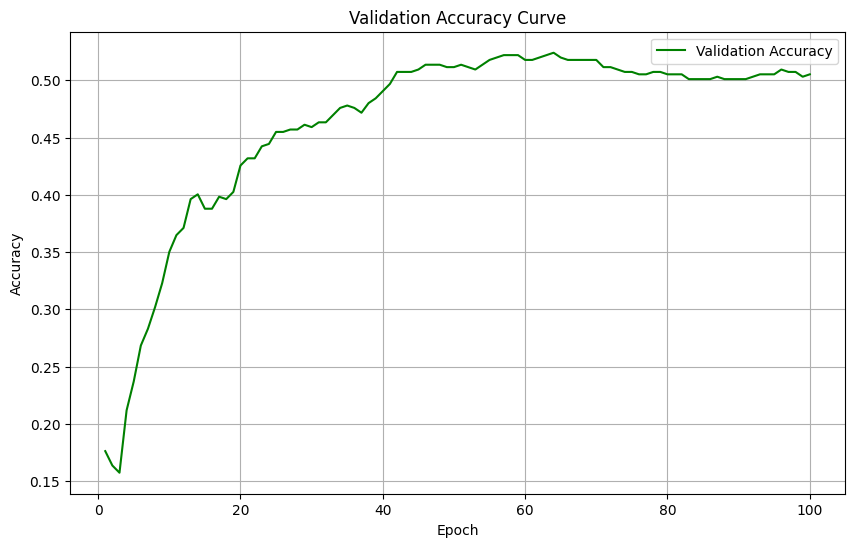

In [ ]:
end_time = time.time()
training_time = end_time - start_time

# Calculate parameter count
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Training Summary ---")
print(f"Sequence Length: {max_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}") # Use the last recorded training loss
print(f"Final Validation Loss: {val_losses[-1]:.4f}") # Use the last recorded validation loss
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}") # Use the last recorded validation accuracy
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {param_count}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


# **Gru model sequnce 20**

In [ ]:
# Preparing the dataset
max_length = 20
X = []
y = []
for i in range(len(text) - max_length):
    sequence = text[i:i + max_length]
    label = text[i + max_length]
    X.append([char_to_ix[char] for char in sequence])
    y.append(char_to_ix[label])

X = np.array(X)
y = np.array(y)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Converting data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [ ]:
# Training the model

start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())
        _, predicted = torch.max(val_output, 1)
        val_accuracy = (predicted == y_val).float().mean()
        val_accuracies.append(val_accuracy.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy.item():.4f}')


Epoch 10, Loss: 0.2990, Validation Loss: 0.8449, Validation Accuracy: 0.8105
Epoch 20, Loss: 0.1417, Validation Loss: 0.9497, Validation Accuracy: 0.7747
Epoch 30, Loss: 0.0745, Validation Loss: 1.0688, Validation Accuracy: 0.7453
Epoch 40, Loss: 0.0451, Validation Loss: 1.1472, Validation Accuracy: 0.7305
Epoch 50, Loss: 0.0309, Validation Loss: 1.1902, Validation Accuracy: 0.7242
Epoch 60, Loss: 0.0236, Validation Loss: 1.2199, Validation Accuracy: 0.7200
Epoch 70, Loss: 0.0195, Validation Loss: 1.2448, Validation Accuracy: 0.7200
Epoch 80, Loss: 0.0169, Validation Loss: 1.2630, Validation Accuracy: 0.7137
Epoch 90, Loss: 0.0152, Validation Loss: 1.2770, Validation Accuracy: 0.7242
Epoch 100, Loss: 0.0139, Validation Loss: 1.2921, Validation Accuracy: 0.7200



--- Training Summary ---
Sequence Length: 20
Final Training Loss: 0.0139
Final Validation Loss: 1.2921
Final Validation Accuracy: 0.7200
Training Time: 124.35 seconds
Parameter Count: 110637


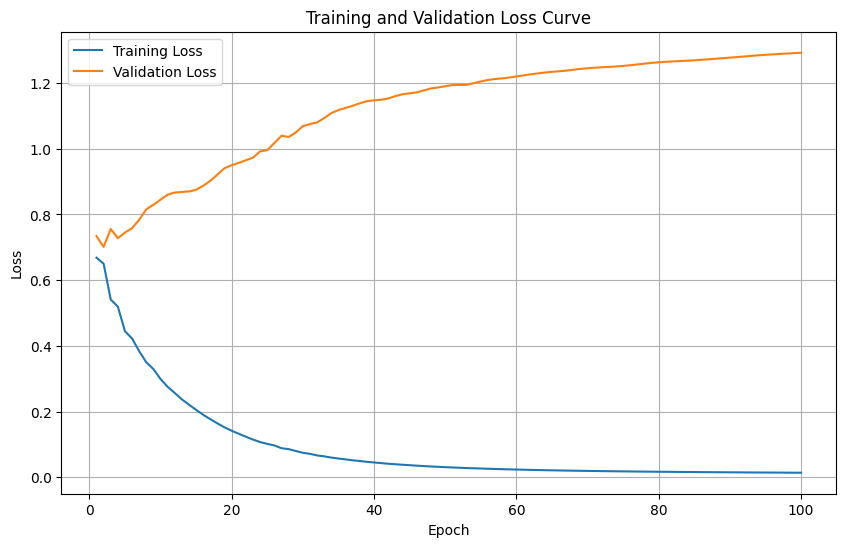

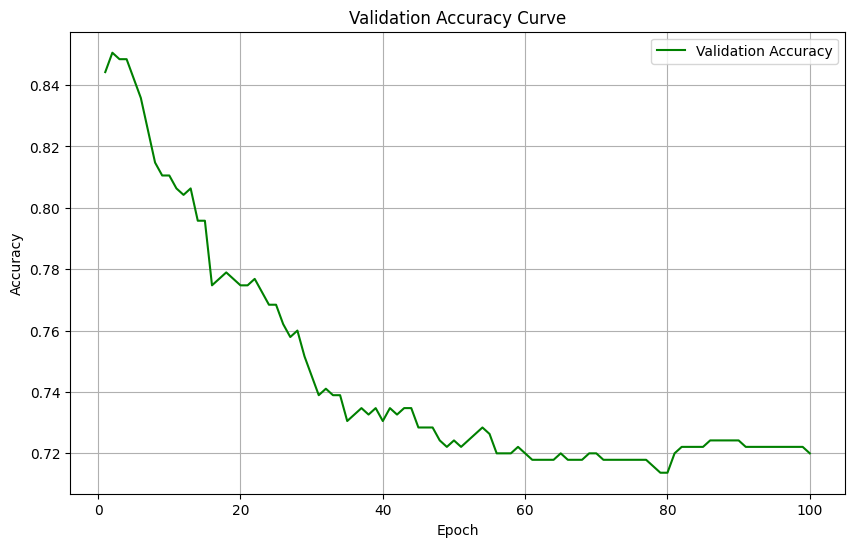

In [ ]:
end_time = time.time()
training_time = end_time - start_time

# Calculate parameter count
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Training Summary ---")
print(f"Sequence Length: {max_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}") # Use the last recorded training loss
print(f"Final Validation Loss: {val_losses[-1]:.4f}") # Use the last recorded validation loss
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}") # Use the last recorded validation accuracy
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {param_count}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


# **GRU - Seqance 30**

In [ ]:
# Preparing the dataset
max_length = 30
X = []
y = []
for i in range(len(text) - max_length):
    sequence = text[i:i + max_length]
    label = text[i + max_length]
    X.append([char_to_ix[char] for char in sequence])
    y.append(char_to_ix[label])

X = np.array(X)
y = np.array(y)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Converting data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [ ]:
# Training the model

start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())
        _, predicted = torch.max(val_output, 1)
        val_accuracy = (predicted == y_val).float().mean()
        val_accuracies.append(val_accuracy.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy.item():.4f}')


Epoch 10, Loss: 0.0884, Validation Loss: 0.4983, Validation Accuracy: 0.8774
Epoch 20, Loss: 0.0404, Validation Loss: 0.5610, Validation Accuracy: 0.8584
Epoch 30, Loss: 0.0232, Validation Loss: 0.5905, Validation Accuracy: 0.8436
Epoch 40, Loss: 0.0270, Validation Loss: 0.6511, Validation Accuracy: 0.8309
Epoch 50, Loss: 0.0149, Validation Loss: 0.6698, Validation Accuracy: 0.8309
Epoch 60, Loss: 0.0116, Validation Loss: 0.6882, Validation Accuracy: 0.8330
Epoch 70, Loss: 0.0099, Validation Loss: 0.6821, Validation Accuracy: 0.8414
Epoch 80, Loss: 0.0089, Validation Loss: 0.6879, Validation Accuracy: 0.8330
Epoch 90, Loss: 0.0082, Validation Loss: 0.6973, Validation Accuracy: 0.8330
Epoch 100, Loss: 0.0086, Validation Loss: 0.7097, Validation Accuracy: 0.8266



--- Training Summary ---
Sequence Length: 30
Final Training Loss: 0.0086
Final Validation Loss: 0.7097
Final Validation Accuracy: 0.8266
Training Time: 89.64 seconds
Parameter Count: 110637


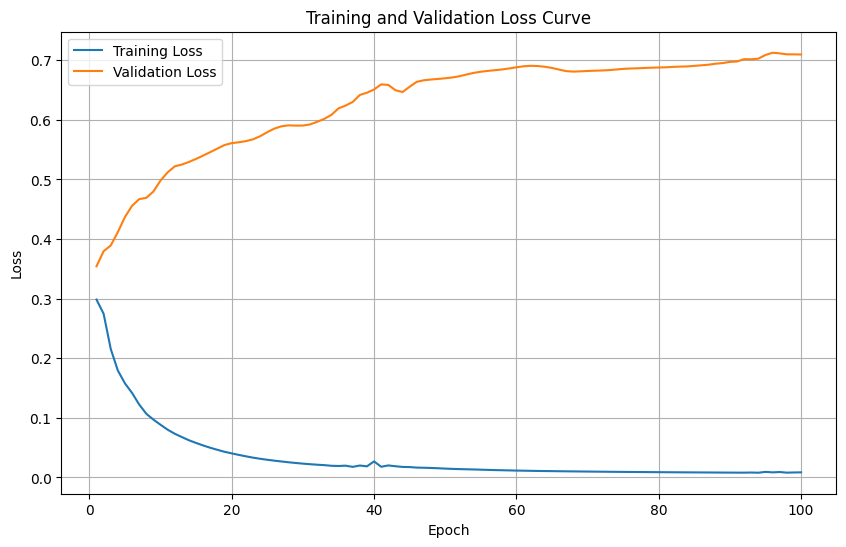

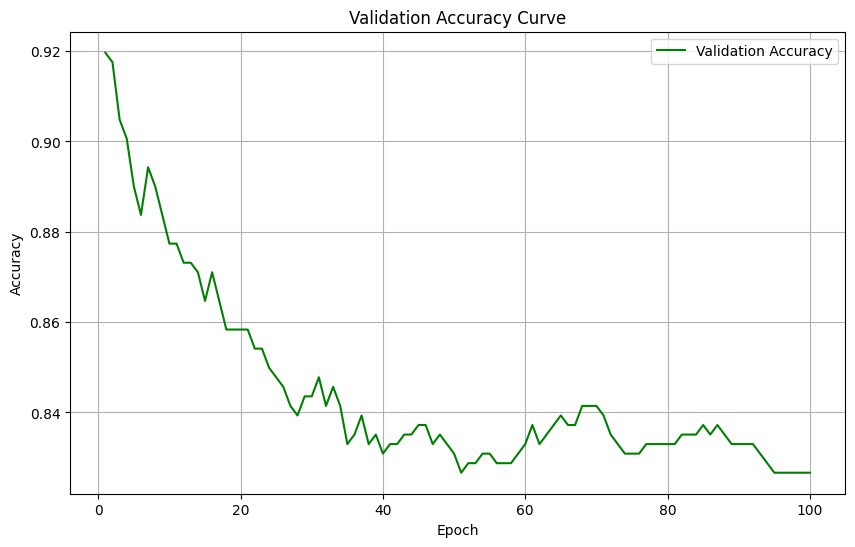

In [ ]:
end_time = time.time()
training_time = end_time - start_time

# Calculate parameter count
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Training Summary ---")
print(f"Sequence Length: {max_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}") # Use the last recorded training loss
print(f"Final Validation Loss: {val_losses[-1]:.4f}") # Use the last recorded validation loss
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}") # Use the last recorded validation accuracy
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {param_count}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


# **Problem 2**

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

In [3]:
# Step 1: Download the dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text  # This is the entire text data



In [4]:
# Step 2: Prepare the dataset
sequence_length = 20
# Create a character mapping to integers
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text into integers
encoded_text = [char_to_int[ch] for ch in text]

In [5]:
# Create sequences and targets
sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

# Convert lists to PyTorch tensors
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# Step 3: Create a dataset class
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

# Instantiate the dataset
dataset = CharDataset(sequences, targets)

# Step 4: Create data loaders
batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

# **LSTM Model**

In [6]:
# Defining the RNN model
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        output = self.fc(output[:, -1, :])
        return output



In [7]:
# Hyperparameters
hidden_size = 128
learning_rate = 0.005
epochs = 10



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CharRNN(len(chars), hidden_size, len(chars)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [8]:
start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            val_output = model(inputs)
            val_loss = criterion(val_output, labels)

            total_val_loss += val_loss.item()
            _, predicted = torch.max(val_output, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_losses.append(total_val_loss / len(test_loader))
    val_accuracy = correct_predictions / total_samples
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch+1}, '
        f'Loss: {train_losses[-1]:.4f}, '
        f'Validation Loss: {val_losses[-1]:.4f}, '
        f'Validation Accuracy: {val_accuracies[-1]:.4f}'
    )

training_time = time.time() - start_time
parameter_count = sum(p.numel() for p in model.parameters())

print("\n--- Training Summary ---")
print(f"Sequence Length: {sequence_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {parameter_count}")



Epoch 1, Loss: 1.7562, Validation Loss: 1.6332, Validation Accuracy: 0.5090
Epoch 2, Loss: 1.5929, Validation Loss: 1.5800, Validation Accuracy: 0.5247
Epoch 3, Loss: 1.5584, Validation Loss: 1.5548, Validation Accuracy: 0.5281
Epoch 4, Loss: 1.5449, Validation Loss: 1.5566, Validation Accuracy: 0.5282
Epoch 5, Loss: 1.5368, Validation Loss: 1.5573, Validation Accuracy: 0.5275
Epoch 6, Loss: 1.5376, Validation Loss: 1.5515, Validation Accuracy: 0.5299
Epoch 7, Loss: 1.5354, Validation Loss: 1.5510, Validation Accuracy: 0.5282
Epoch 8, Loss: 1.5349, Validation Loss: 1.5529, Validation Accuracy: 0.5275
Epoch 9, Loss: 1.5358, Validation Loss: 1.5510, Validation Accuracy: 0.5309
Epoch 10, Loss: 1.5369, Validation Loss: 1.5621, Validation Accuracy: 0.5279

--- Training Summary ---
Sequence Length: 20
Final Training Loss: 1.5369
Final Validation Loss: 1.5621
Final Validation Accuracy: 0.5279
Training Time: 250.33 seconds
Parameter Count: 148801


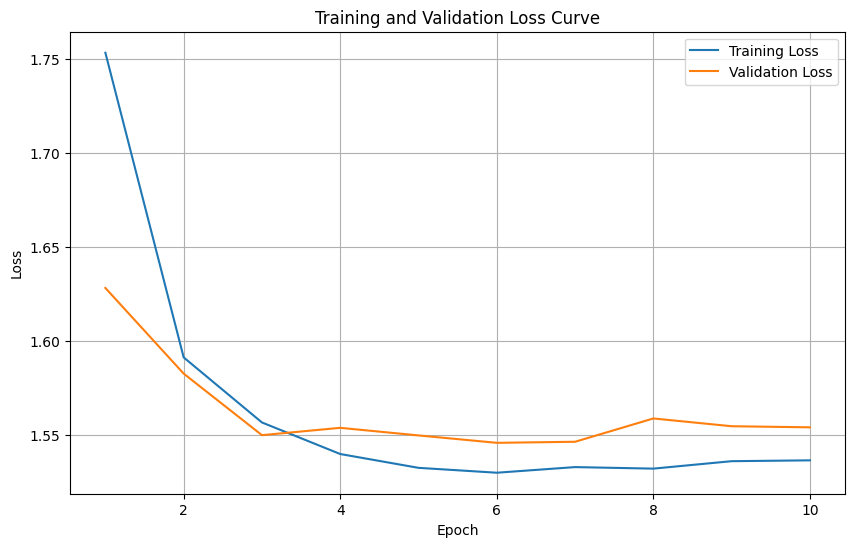

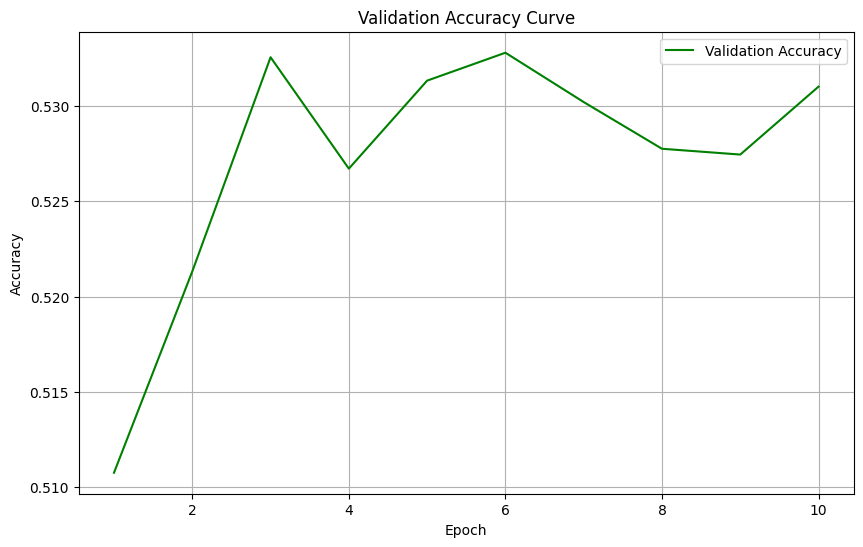

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# **LSTM seqeunce 30**

In [ ]:

sequence_length = 30
# Create a character mapping to integers
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text into integers
encoded_text = [char_to_int[ch] for ch in text]

In [ ]:
# Create sequences and targets
sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

# Convert lists to PyTorch tensors
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# Step 3: Create a dataset class
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

# Instantiate the dataset
dataset = CharDataset(sequences, targets)

# Step 4: Create data loaders
batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

In [ ]:
start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            val_output = model(inputs)
            val_loss = criterion(val_output, labels)

            total_val_loss += val_loss.item()
            _, predicted = torch.max(val_output, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_losses.append(total_val_loss / len(test_loader))
    val_accuracy = correct_predictions / total_samples
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch+1}, '
        f'Loss: {train_losses[-1]:.4f}, '
        f'Validation Loss: {val_losses[-1]:.4f}, '
        f'Validation Accuracy: {val_accuracies[-1]:.4f}'
    )

training_time = time.time() - start_time
parameter_count = sum(p.numel() for p in model.parameters())

print("\n--- Training Summary ---")
print(f"Sequence Length: {sequence_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {parameter_count}")

Epoch 1, Loss: 1.5405, Validation Loss: 1.5455, Validation Accuracy: 0.5343
Epoch 2, Loss: 1.5420, Validation Loss: 1.5379, Validation Accuracy: 0.5339
Epoch 3, Loss: 1.5447, Validation Loss: 1.5497, Validation Accuracy: 0.5305
Epoch 4, Loss: 1.5509, Validation Loss: 1.5577, Validation Accuracy: 0.5271
Epoch 5, Loss: 1.5569, Validation Loss: 1.5628, Validation Accuracy: 0.5261
Epoch 6, Loss: 1.5607, Validation Loss: 1.5589, Validation Accuracy: 0.5300
Epoch 7, Loss: 1.5645, Validation Loss: 1.5682, Validation Accuracy: 0.5273
Epoch 8, Loss: 1.5725, Validation Loss: 1.5704, Validation Accuracy: 0.5272
Epoch 9, Loss: 1.5780, Validation Loss: 1.5845, Validation Accuracy: 0.5210
Epoch 10, Loss: 1.5894, Validation Loss: 1.5989, Validation Accuracy: 0.5193

--- Training Summary ---
Sequence Length: 30
Final Training Loss: 1.5894
Final Validation Loss: 1.5989
Final Validation Accuracy: 0.5193
Training Time: 269.68 seconds
Parameter Count: 148801


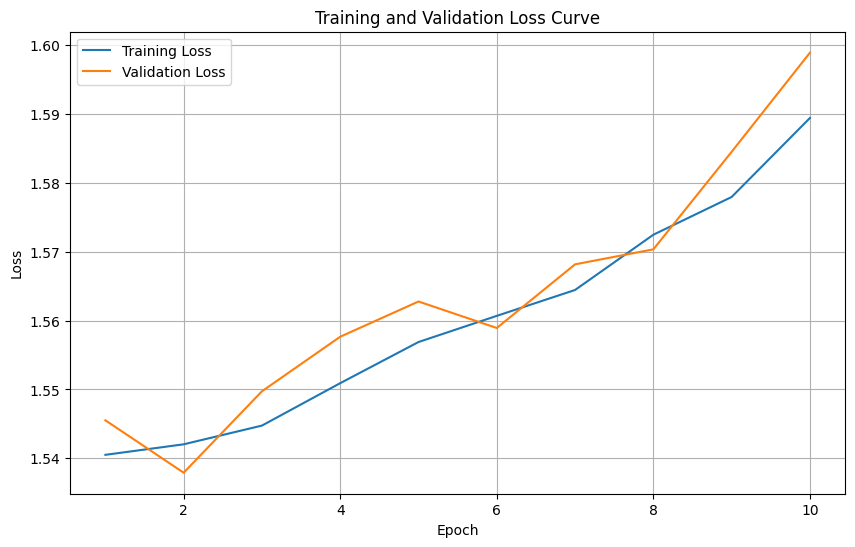

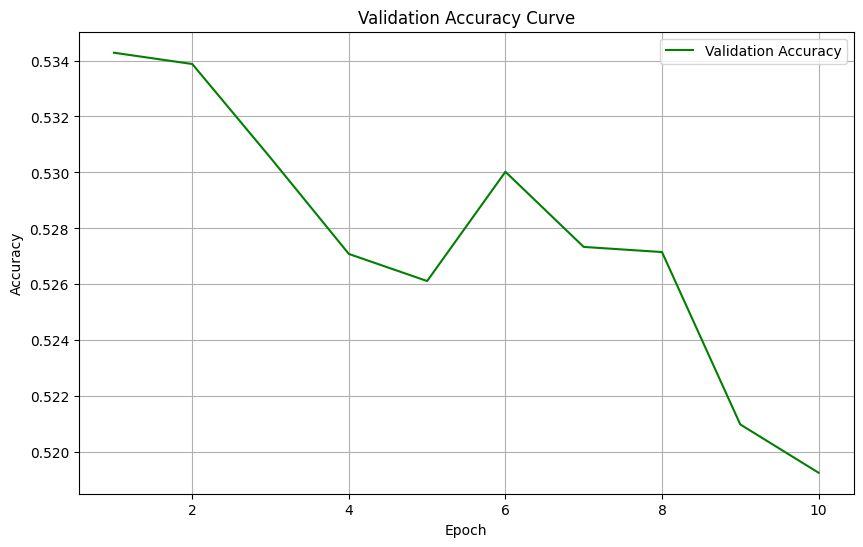

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# **RNN.GRU Model**

In [ ]:
# Step 2: Prepare the dataset
sequence_length = 20
# Create a character mapping to integers
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text into integers
encoded_text = [char_to_int[ch] for ch in text]

In [ ]:
# Create sequences and targets
sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

# Convert lists to PyTorch tensors
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# Step 3: Create a dataset class
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

# Instantiate the dataset
dataset = CharDataset(sequences, targets)

# Step 4: Create data loaders
batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

In [ ]:
# Defining the RNN model
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        output = self.fc(output[:, -1, :])
        return output



In [ ]:
# Hyperparameters
hidden_size = 128
learning_rate = 0.005
epochs = 10



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CharRNN(len(chars), hidden_size, len(chars)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            val_output = model(inputs)
            val_loss = criterion(val_output, labels)

            total_val_loss += val_loss.item()
            _, predicted = torch.max(val_output, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_losses.append(total_val_loss / len(test_loader))
    val_accuracy = correct_predictions / total_samples
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch+1}, '
        f'Loss: {train_losses[-1]:.4f}, '
        f'Validation Loss: {val_losses[-1]:.4f}, '
        f'Validation Accuracy: {val_accuracies[-1]:.4f}'
    )

training_time = time.time() - start_time
parameter_count = sum(p.numel() for p in model.parameters())

print("\n--- Training Summary ---")
print(f"Sequence Length: {sequence_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {parameter_count}")

Epoch 1, Loss: 1.8475, Validation Loss: 1.7661, Validation Accuracy: 0.4815
Epoch 2, Loss: 1.7568, Validation Loss: 1.7596, Validation Accuracy: 0.4785
Epoch 3, Loss: 1.7568, Validation Loss: 1.7677, Validation Accuracy: 0.4804
Epoch 4, Loss: 1.7696, Validation Loss: 1.7638, Validation Accuracy: 0.4784
Epoch 5, Loss: 1.7768, Validation Loss: 1.8119, Validation Accuracy: 0.4702
Epoch 6, Loss: 1.7878, Validation Loss: 1.8124, Validation Accuracy: 0.4638
Epoch 7, Loss: 1.8083, Validation Loss: 1.8032, Validation Accuracy: 0.4711
Epoch 8, Loss: 1.8086, Validation Loss: 1.8030, Validation Accuracy: 0.4725
Epoch 9, Loss: 1.8196, Validation Loss: 1.8286, Validation Accuracy: 0.4657
Epoch 10, Loss: 1.8185, Validation Loss: 1.8285, Validation Accuracy: 0.4650

--- Training Summary ---
Sequence Length: 20
Final Training Loss: 1.8185
Final Validation Loss: 1.8285
Final Validation Accuracy: 0.4650
Training Time: 232.73 seconds
Parameter Count: 115777


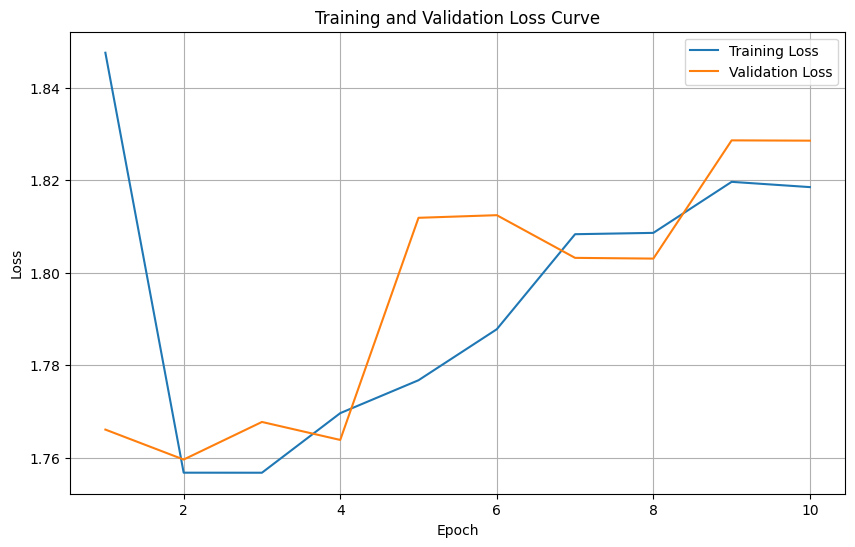

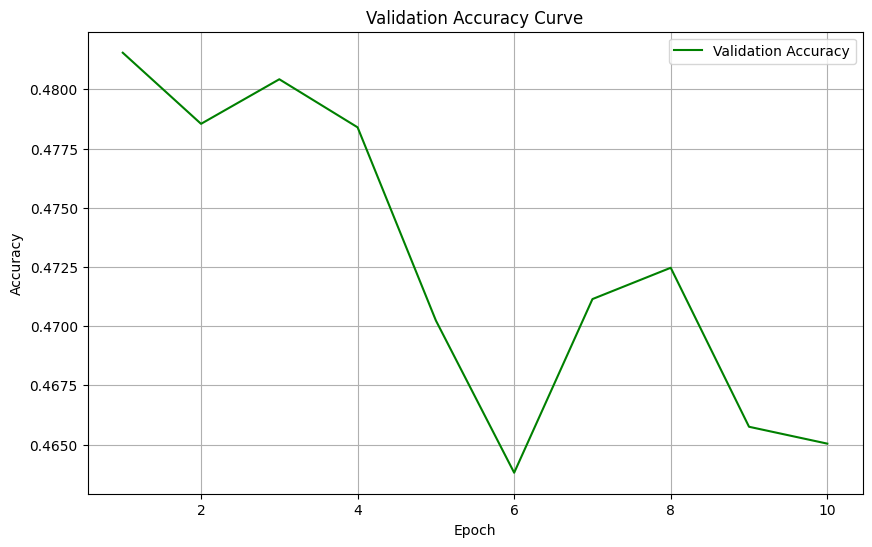

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# **GRU sequence of 30**

In [ ]:

sequence_length = 30
# Create a character mapping to integers
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text into integers
encoded_text = [char_to_int[ch] for ch in text]

In [ ]:
# Create sequences and targets
sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

# Convert lists to PyTorch tensors
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# Step 3: Create a dataset class
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

# Instantiate the dataset
dataset = CharDataset(sequences, targets)

# Step 4: Create data loaders
batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

In [ ]:
start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            val_output = model(inputs)
            val_loss = criterion(val_output, labels)

            total_val_loss += val_loss.item()
            _, predicted = torch.max(val_output, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_losses.append(total_val_loss / len(test_loader))
    val_accuracy = correct_predictions / total_samples
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch+1}, '
        f'Loss: {train_losses[-1]:.4f}, '
        f'Validation Loss: {val_losses[-1]:.4f}, '
        f'Validation Accuracy: {val_accuracies[-1]:.4f}'
    )

training_time = time.time() - start_time
parameter_count = sum(p.numel() for p in model.parameters())

print("\n--- Training Summary ---")
print(f"Sequence Length: {sequence_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {parameter_count}")

Epoch 1, Loss: 1.8233, Validation Loss: 1.8479, Validation Accuracy: 0.4570
Epoch 2, Loss: 1.8216, Validation Loss: 1.8486, Validation Accuracy: 0.4504
Epoch 3, Loss: 1.8284, Validation Loss: 1.8438, Validation Accuracy: 0.4647
Epoch 4, Loss: 1.8307, Validation Loss: 1.8392, Validation Accuracy: 0.4622
Epoch 5, Loss: 1.8288, Validation Loss: 1.8364, Validation Accuracy: 0.4552
Epoch 6, Loss: 1.8245, Validation Loss: 1.8427, Validation Accuracy: 0.4623
Epoch 7, Loss: 1.8247, Validation Loss: 1.8323, Validation Accuracy: 0.4660
Epoch 8, Loss: 1.8330, Validation Loss: 1.8381, Validation Accuracy: 0.4635
Epoch 9, Loss: 1.8272, Validation Loss: 1.8517, Validation Accuracy: 0.4577
Epoch 10, Loss: 1.8317, Validation Loss: 1.8474, Validation Accuracy: 0.4572

--- Training Summary ---
Sequence Length: 30
Final Training Loss: 1.8317
Final Validation Loss: 1.8474
Final Validation Accuracy: 0.4572
Training Time: 248.03 seconds
Parameter Count: 115777


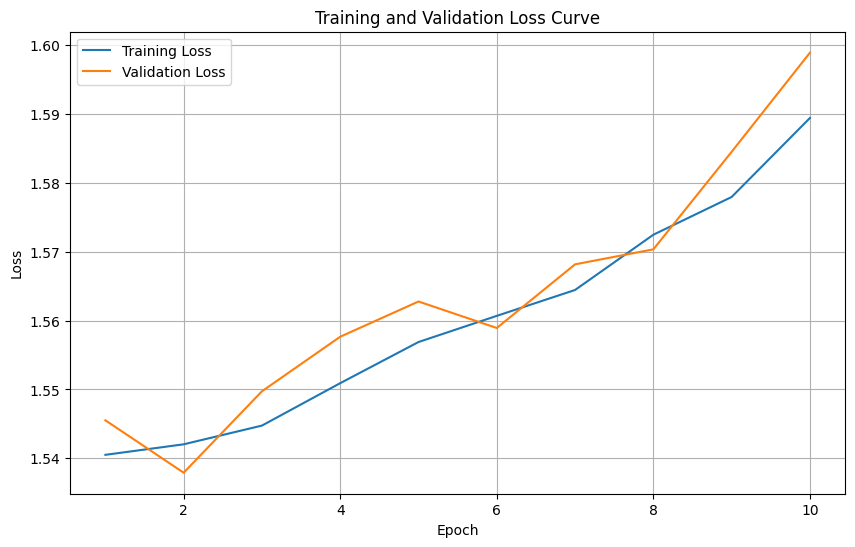

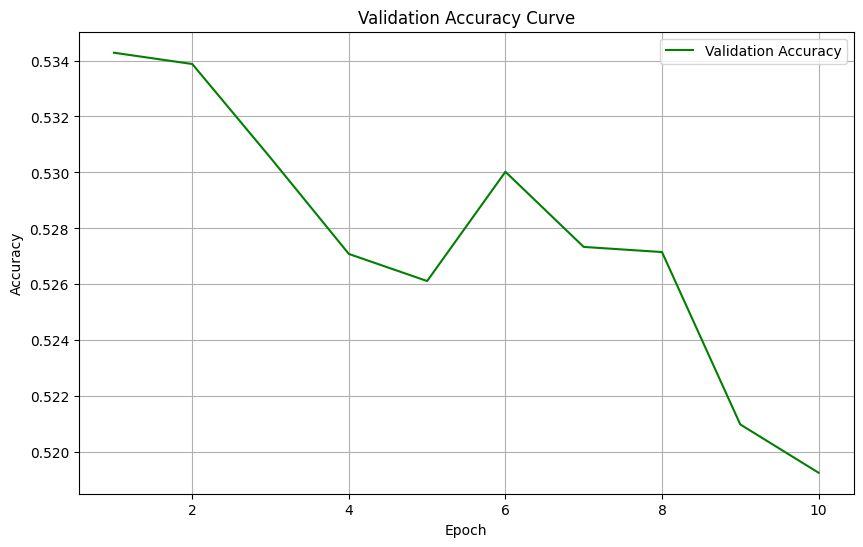

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# **Part 2**

In [ ]:

sequence_length = 20
# Create a character mapping to integers
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text into integers
encoded_text = [char_to_int[ch] for ch in text]

In [ ]:
# Create sequences and targets
sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

# Convert lists to PyTorch tensors
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# Step 3: Create a dataset class
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

# Instantiate the dataset
dataset = CharDataset(sequences, targets)

# Step 4: Create data loaders
batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

In [ ]:
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, fc_hidden=False):
        super(CharRNN, self).__init__()

        self.embedding = nn.Embedding(input_size, hidden_size)

        self.rnn = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        if fc_hidden:
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, output_size)
            )
        else:
            self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        output = self.fc(output[:, -1, :])
        return output

In [ ]:
#For various test change these three values -
hidden_size = 128
num_layers = 2
fc_hidden = False

model = CharRNN(
    input_size=len(chars),
    hidden_size=hidden_size,
    output_size=len(chars),
    num_layers=num_layers,
    fc_hidden=fc_hidden
).to(device)

In [ ]:
print(model)
print("LSTM layers:", model.rnn.num_layers)
print("Parameter Count:", sum(p.numel() for p in model.parameters()))

CharRNN(
  (embedding): Embedding(65, 128)
  (rnn): GRU(128, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=65, bias=True)
)
LSTM layers: 2
Parameter Count: 214849


In [ ]:
learning_rate = 0.005
epochs = 10



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CharRNN(
    input_size=len(chars),
    hidden_size=hidden_size,
    output_size=len(chars),
    num_layers=num_layers,
    fc_hidden=fc_hidden
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            val_output = model(inputs)
            val_loss = criterion(val_output, labels)

            total_val_loss += val_loss.item()
            _, predicted = torch.max(val_output, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_losses.append(total_val_loss / len(test_loader))
    val_accuracy = correct_predictions / total_samples
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch+1}, '
        f'Loss: {train_losses[-1]:.4f}, '
        f'Validation Loss: {val_losses[-1]:.4f}, '
        f'Validation Accuracy: {val_accuracies[-1]:.4f}'
    )

training_time = time.time() - start_time
parameter_count = sum(p.numel() for p in model.parameters())

print("\n--- Training Summary ---")
print(f"Sequence Length: {sequence_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {parameter_count}")

# --- Inference Time Calculation ---
# Take a sample input from the validation set
model.eval()
with torch.no_grad():
    sample_input, _ = test_dataset[0]
    sample_input = sample_input.unsqueeze(0).to(device) # Add batch dimension

    inference_start_time = time.time()
    _ = model(sample_input)
    inference_time = time.time() - inference_start_time
    print(f"Inference Time (per sample): {inference_time:.6f} seconds")

# --- Generate Output Sequence ---
def generate_text(model, start_string, num_generate=50, temperature=1.0):
    model.eval()
    input_eval = [char_to_int[s] for s in start_string]
    input_eval = torch.tensor(input_eval, dtype=torch.long).unsqueeze(0).to(device)

    text_generated = []
    # Here we are limiting to the `sequence_length` used for training
    # and generating `num_generate` characters after that.
    model.eval()
    with torch.no_grad():
        for i in range(num_generate):
            predictions = model(input_eval)
            predictions = predictions.squeeze(0) / temperature
            predicted_id = torch.multinomial(torch.softmax(predictions, dim=0), 1).item()

            input_eval = torch.cat([input_eval[:, 1:], torch.tensor([[predicted_id]], dtype=torch.long).to(device)], dim=1)
            text_generated.append(int_to_char[predicted_id])

    return start_string + ''.join(text_generated)

start_prompt = "The quick brown fox jumps over the lazy dog."
if len(start_prompt) < sequence_length:
    start_prompt = start_prompt.ljust(sequence_length, ' ')
else:
    start_prompt = start_prompt[:sequence_length]

generated_text = generate_text(model, start_prompt, num_generate=50)
print(f"\nGenerated Output Sequence: {generated_text}")

Epoch 1, Loss: 1.8612, Validation Loss: 1.8045, Validation Accuracy: 0.4677
Epoch 2, Loss: 1.8364, Validation Loss: 1.8622, Validation Accuracy: 0.4515
Epoch 3, Loss: 1.8870, Validation Loss: 1.8984, Validation Accuracy: 0.4462
Epoch 4, Loss: 1.9168, Validation Loss: 1.9264, Validation Accuracy: 0.4349
Epoch 5, Loss: 1.9517, Validation Loss: 1.9839, Validation Accuracy: 0.4252
Epoch 6, Loss: 1.9782, Validation Loss: 2.0067, Validation Accuracy: 0.4190
Epoch 7, Loss: 2.0493, Validation Loss: 2.0522, Validation Accuracy: 0.4143
Epoch 8, Loss: 2.0531, Validation Loss: 2.0609, Validation Accuracy: 0.3976
Epoch 9, Loss: 2.0910, Validation Loss: 2.1627, Validation Accuracy: 0.3833
Epoch 10, Loss: 2.2032, Validation Loss: 2.2670, Validation Accuracy: 0.3480

--- Training Summary ---
Sequence Length: 20
Final Training Loss: 2.2032
Final Validation Loss: 2.2670
Final Validation Accuracy: 0.3480
Training Time: 267.44 seconds
Parameter Count: 214849
Inference Time (per sample): 0.000432 seconds



# **Part 3**

# **LSTM Model**

In [ ]:
# Step 2: Prepare the dataset
sequence_length = 50
# Create a character mapping to integers
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text into integers
encoded_text = [char_to_int[ch] for ch in text]

In [ ]:
# Create sequences and targets
sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

# Convert lists to PyTorch tensors
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# Step 3: Create a dataset class
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

# Instantiate the dataset
dataset = CharDataset(sequences, targets)

# Step 4: Create data loaders
batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

In [ ]:
# Defining the RNN model
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        output = self.fc(output[:, -1, :])
        return output



In [ ]:
# Hyperparameters
hidden_size = 128
learning_rate = 0.005
epochs = 10



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CharRNN(len(chars), hidden_size, len(chars)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            val_output = model(inputs)
            val_loss = criterion(val_output, labels)

            total_val_loss += val_loss.item()
            _, predicted = torch.max(val_output, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_losses.append(total_val_loss / len(test_loader))
    val_accuracy = correct_predictions / total_samples
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch+1}, '
        f'Loss: {train_losses[-1]:.4f}, '
        f'Validation Loss: {val_losses[-1]:.4f}, '
        f'Validation Accuracy: {val_accuracies[-1]:.4f}'
    )

training_time = time.time() - start_time
parameter_count = sum(p.numel() for p in model.parameters())

print("\n--- Training Summary ---")
print(f"Sequence Length: {sequence_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {parameter_count}")



Epoch 1, Loss: 1.7557, Validation Loss: 1.6288, Validation Accuracy: 0.5114
Epoch 2, Loss: 1.5934, Validation Loss: 1.5886, Validation Accuracy: 0.5253
Epoch 3, Loss: 1.5593, Validation Loss: 1.5588, Validation Accuracy: 0.5340
Epoch 4, Loss: 1.5415, Validation Loss: 1.5432, Validation Accuracy: 0.5361
Epoch 5, Loss: 1.5340, Validation Loss: 1.5395, Validation Accuracy: 0.5357
Epoch 6, Loss: 1.5333, Validation Loss: 1.5431, Validation Accuracy: 0.5358
Epoch 7, Loss: 1.5325, Validation Loss: 1.5471, Validation Accuracy: 0.5334
Epoch 8, Loss: 1.5360, Validation Loss: 1.5469, Validation Accuracy: 0.5332
Epoch 9, Loss: 1.5393, Validation Loss: 1.5541, Validation Accuracy: 0.5325
Epoch 10, Loss: 1.5395, Validation Loss: 1.5467, Validation Accuracy: 0.5325

--- Training Summary ---
Sequence Length: 50
Final Training Loss: 1.5395
Final Validation Loss: 1.5467
Final Validation Accuracy: 0.5325
Training Time: 335.56 seconds
Parameter Count: 148801


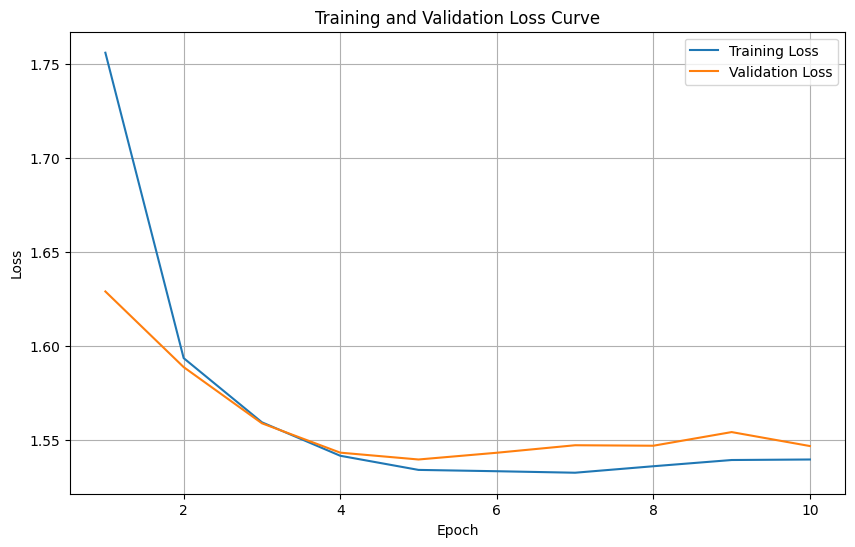

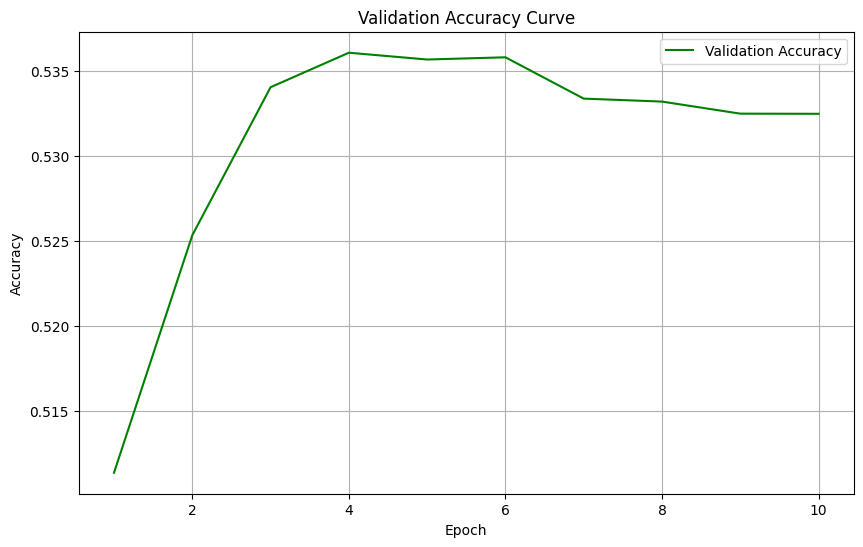

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# **GRU Model: **

In [ ]:
# Defining the RNN model
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        output = self.fc(output[:, -1, :])
        return output



In [ ]:
# Hyperparameters
hidden_size = 128
learning_rate = 0.005
epochs = 10



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CharRNN(len(chars), hidden_size, len(chars)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            val_output = model(inputs)
            val_loss = criterion(val_output, labels)

            total_val_loss += val_loss.item()
            _, predicted = torch.max(val_output, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_losses.append(total_val_loss / len(test_loader))
    val_accuracy = correct_predictions / total_samples
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch+1}, '
        f'Loss: {train_losses[-1]:.4f}, '
        f'Validation Loss: {val_losses[-1]:.4f}, '
        f'Validation Accuracy: {val_accuracies[-1]:.4f}'
    )

training_time = time.time() - start_time
parameter_count = sum(p.numel() for p in model.parameters())

print("\n--- Training Summary ---")
print(f"Sequence Length: {sequence_length}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameter Count: {parameter_count}")



Epoch 1, Loss: 1.8419, Validation Loss: 1.7616, Validation Accuracy: 0.4876
Epoch 2, Loss: 1.7436, Validation Loss: 1.7406, Validation Accuracy: 0.4829
Epoch 3, Loss: 1.7435, Validation Loss: 1.7500, Validation Accuracy: 0.4778
Epoch 4, Loss: 1.7568, Validation Loss: 1.7692, Validation Accuracy: 0.4804
Epoch 5, Loss: 1.7620, Validation Loss: 1.7771, Validation Accuracy: 0.4789
Epoch 6, Loss: 1.7772, Validation Loss: 1.7896, Validation Accuracy: 0.4716
Epoch 7, Loss: 1.7815, Validation Loss: 1.7971, Validation Accuracy: 0.4697
Epoch 8, Loss: 1.7955, Validation Loss: 1.7911, Validation Accuracy: 0.4760
Epoch 9, Loss: 1.8013, Validation Loss: 1.8416, Validation Accuracy: 0.4644
Epoch 10, Loss: 1.8066, Validation Loss: 1.8111, Validation Accuracy: 0.4671

--- Training Summary ---
Sequence Length: 50
Final Training Loss: 1.8066
Final Validation Loss: 1.8111
Final Validation Accuracy: 0.4671
Training Time: 265.32 seconds
Parameter Count: 115777


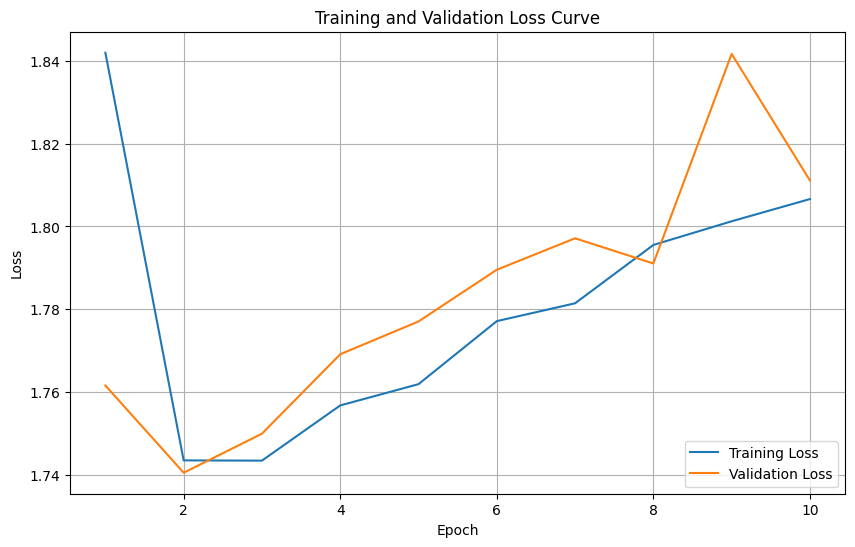

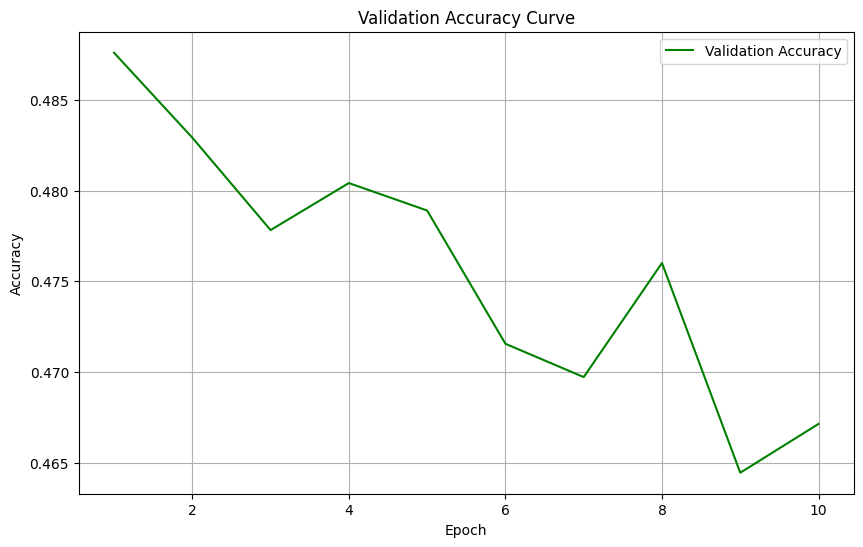

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()